In [37]:
import pandas as pd
import psycopg2

# PostgreSQL 연결
conn = psycopg2.connect(
    dbname="mydb",
    user="user",
    password="pass",
    host="my_postgres",
    port="5432"
)

# Pandas로 데이터 불러오기
df = pd.read_sql(
    """SELECT *
       FROM new_review""", conn)
print(df.head())

conn.close()


/tmp/ipykernel_2018592/3562102429.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


   index  recipe_number  recipe_code         recipe_name  \
0      0              1        14299  Creamy White Chili   
1      1              1        14299  Creamy White Chili   
2      2              1        14299  Creamy White Chili   
3      3              1        14299  Creamy White Chili   
4      4              1        14299  Creamy White Chili   

                                        comment_id         user_id  \
0  sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM  u_9iFLIhMa8QaG   
1  sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY  u_Lu6p25tmE77j   
2  sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP  u_s0LwgpZ8Jsqq   
3  sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC  u_fqrybAdYjgjG   
4  sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI  u_XXWKwVhKZD69   

    user_name  user_reputation  created_at  reply_count  ...  \
0     Jeri326                1  1665619889            0  ...   
1     Mark467               50  1665277687            0  ...   
2  Barbara566             

In [38]:
# text preprocessing

def text_process(col):
    col = col.lower()
    # remove meaningless words
    stoplists = ['and', 'but', 'for', 'nor', 'yet', 'the', 'via', 'per', 'also', 'thus', 'once', 'from', 'with', 'into', 'onto',
                 'over', 'near', 'like', 'upon', 'such', 'some', 'that', '.', ',', 'our', 'was', 'were', 'did', "didn't", 'now', 'this', 'that'
                 , 'recipe', 'make', 'made', 'have', 'used', 'you', 'will']
    for s in stoplists:
        col = col.replace(s, '')
    splited_text = col.split(' ')
    # remove keywords which length is under 2
    splited_text = [k for k in splited_text if len(k) > 2]
    return splited_text


In [66]:
df['keyword_ls'] = df.text.apply(lambda x: text_process(x))
df['feature'] = df['feature'].apply(lambda x: x.replace(' ', '').split(','))


In [105]:
print('Keywords list 0 : ', df.keyword_ls[0])
print('Keywords list 1 : ', df.keyword_ls[1])
print('Keywords list 2 : ', df.keyword_ls[2])


Keywords list 0 :  ['tweaked', 'little', 'removed', 'onions', 'because', 'onion', 'haters', 'house', 'italian', 'seasoning', 'instead', 'just', 'oregano', 'use', 'paprika/', 'cayenne', 'mix', 'little', 'more', 'than', 'called', 'everything', 'bit', 'more', 'hot', 'chili', 'amazing!', 'easy', 'everyone', 'absolutely', 'loved', 'staple', 'meal', 'house']
Keywords list 1 :  ['bush', 'white', 'chili', 'bean', 'simple', 'i’ve', 'written', 'asked', 'please!', 'bring', 'back']
Keywords list 2 :  ['very', 'complicated', 'white', 'chicken', 'chili', 'years', 'everyone', 'raves', 'saw', 'thought', 'i’d', 'try', 'easy', 'alternative', 'weeknights', 'husb', 'better!', 'easy', 'delicious!', 'cut', 'back', 'slightly', 'crushed', 'oregano', 'cayenne', 'pep', 'orwise', 'exactly', 'written']


In [67]:
# make dictionary for each recipe to observe frequent keywords
from itertools import chain
from collections import Counter
category = df.food_category.unique().tolist()
recipe_dict = dict()
for c in category:
    ls = df.loc[df.food_category == c]['keyword_ls'].tolist()
    ls = list(chain(*ls))
    cnt_dict = dict(Counter(ls))
    cnt_dict = dict(
        sorted(cnt_dict.items(), key=lambda item: item[1], reverse=True))
    recipe_dict[c] = cnt_dict


In [106]:
recipe_dict['Salad']


{'sugar': 91,
 'cream': 76,
 'jello': 59,
 'not': 57,
 'strawberries': 57,
 'salad': 55,
 'family': 48,
 'grapes': 46,
 'cheese': 45,
 'great': 44,
 'brown': 44,
 'use': 44,
 'had': 43,
 'very': 42,
 'years': 42,
 'time': 42,
 'love': 41,
 'always': 40,
 'one': 39,
 'making': 38,
 'bee': 38,
 'good': 36,
 'just': 36,
 'delicious': 34,
 'too': 33,
 'layer': 33,
 'all': 31,
 'fresh': 31,
 'sweet': 30,
 'add': 30,
 'out': 30,
 'everyone': 29,
 'easy': 28,
 'would': 28,
 'been': 27,
 'instead': 27,
 'it&#39;s': 26,
 'pretzels': 26,
 'dish': 25,
 'dessert': 25,
 'about': 25,
 'only': 24,
 'next': 24,
 'day': 24,
 'frozen': 24,
 'really': 23,
 'pecans': 23,
 'top': 23,
 'again': 23,
 'crust': 23,
 'are': 22,
 'taste': 22,
 'way': 22,
 'added': 21,
 'loved': 21,
 'get': 21,
 'can': 21,
 'mixture': 21,
 'set': 21,
 'n&#39;t': 20,
 'loves': 20,
 'cool': 19,
 'because': 19,
 'after': 19,
 'what': 19,
 'any': 19,
 'off': 18,
 'i&#39;ve': 18,
 'times': 18,
 'it!': 18,
 'cut': 18,
 'put': 18,
 'sti

In [68]:
recipe_dict.keys()

dict_keys(['Soup/Chili', 'Desserts/Pie', 'Salad', 'Pasta/Lasagna', 'Bread/Bakery', 'Soup', 'Casserole/Mexican', 'Breakfast/Casserole', 'Tex-Mex/Chicken', 'Desserts/Bakery', 'Soup/Vegetarian', 'Pot Pie/Comfort Food', 'Main Dish/Chicken', 'Desserts/Cake', 'Salad/Side', 'Desserts/Crisp', 'Main Dish/Cajun', 'Casserole', 'Main Dish/Meat', 'Desserts', 'Soup/Pasta', 'Pasta/Casserole', 'Soup/Chowder', 'Fusion/Lasagna', 'Seafood', 'Desserts/Cheesecake', 'Side Dish', 'Mexican', 'Breakfast', 'Desserts/Cookies', 'Candy/Sweets', 'Pasta/Vegan', 'Casserole/Pasta', 'Soup/Casserole', 'Pasta/Side', 'Mexican/Tacos', 'Desserts/Candy', 'Main Dish/Meatballs', 'Sandwiches/Sliders', 'Casserole/Side', 'Desserts/Pudding', 'Asian/Noodle'])

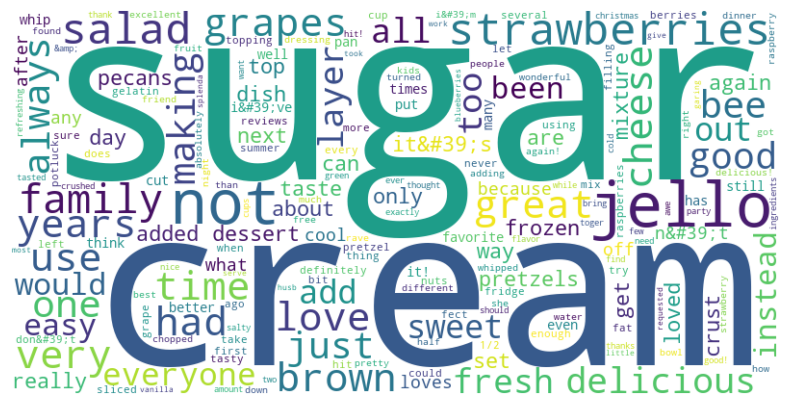

In [107]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# ask for user to enter the recipe name
selected_key = input(
    f"recipe name: {list(recipe_dict.keys())}\nenter the recipe that you want to fine: ")

# If the recipe's name is existed, create wordcloud by using sub-dictionary
if selected_key in recipe_dict:
    selected_data = recipe_dict[selected_key]

    # create wordcloud
    wordcloud = WordCloud(
        width=800, height=400, background_color='white').generate_from_frequencies(selected_data)

    # represent wordcloud graph
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()
else:
    print(f"{selected_key} is not in the list. Please re-enter the recipe")


In [70]:
# extract top 5 recipe 
top5 = list(df.groupby(['food_category'])[['agg_rating']].mean().sort_values(['agg_rating'], ascending = False).head(5).index)

# extract low 5 recipe 

tail5 = list(df.groupby(['food_category'])[['agg_rating']].mean().sort_values(['agg_rating']).head(5).index)


In [71]:
# top5 recipe's rating
print(df.loc[df.food_category =='Casserole/Pasta'].groupby(['recipe_name'])[['agg_rating','stars']].mean())

print(df.loc[df.food_category == 'Sandwiches/Sliders'].groupby(['recipe_name'])
      [['agg_rating', 'stars']].mean())

print(df.loc[df.food_category == 'Desserts'].groupby(
    ['recipe_name'])[['agg_rating', 'stars']].mean())

print(df.loc[df.food_category == 'Breakfast/Casserole'].groupby(['recipe_name'])
      [['agg_rating', 'stars']].mean())

print(df.loc[df.food_category =='Pasta/Vegan'].groupby(['recipe_name'])[['agg_rating','stars']].mean())

                         agg_rating     stars
recipe_name                                  
Chicken Penne Casserole    3.278329  4.440945
                       agg_rating     stars
recipe_name                                
Ham and Swiss Sliders    3.278143  4.570175
                                 agg_rating     stars
recipe_name                                          
Peanut Butter Chocolate Dessert     3.15869  4.407895
                           agg_rating     stars
recipe_name                                    
Amish Breakfast Casserole    3.146271  4.526627
                     agg_rating     stars
recipe_name                              
Vegetarian Linguine     3.12672  4.419355


In [72]:
import itertools
from collections import Counter
from itertools import chain
# make dictionary for each recipe to observe frequent keywords
category = df.food_category.unique().tolist()
ls = df.loc[df.food_category.isin(top5)]['keyword_ls'].tolist()
ls = list(chain(*ls))
cnt_dict = dict(Counter(ls))
cnt_dict_top5 = dict(
    sorted(cnt_dict.items(), key=lambda item: item[1], reverse=True))

top_hash_tag = df.loc[df.food_category.isin(top5)]['feature'].tolist()
top_flattened_list = list(itertools.chain(*top_hash_tag))


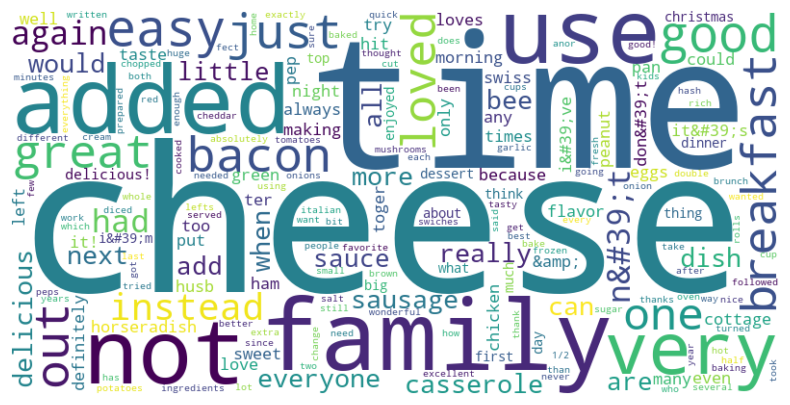

In [73]:
wordcloud = WordCloud(
    width=800, height=400, background_color='white').generate_from_frequencies(cnt_dict_top5)

# represent wordcloud graph
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [74]:
set(top_flattened_list)


{'#Amish',
 '#breakfast',
 '#casserole',
 '#chicken',
 '#chocolate',
 '#dessert',
 '#ham',
 '#hearty',
 '#light',
 '#linguine',
 '#pasta',
 '#peanutbutter',
 '#penne',
 '#savory',
 '#sliders',
 '#sweet',
 '#swiss',
 '#vegetarian'}

In [75]:
# tail5 recipe's rating
print(df.loc[df.food_category == 'Desserts/Cheesecake'].groupby(['recipe_name'])
      [['agg_rating', 'stars']].mean())

print(df.loc[df.food_category == 'Desserts/Pie'].groupby(['recipe_name'])
      [['agg_rating', 'stars']].mean())

print(df.loc[df.food_category == 'Casserole/Side'].groupby(['recipe_name'])
      [['agg_rating', 'stars']].mean())

print(df.loc[df.food_category == 'Desserts/Crisp'].groupby(['recipe_name'])
      [['agg_rating', 'stars']].mean())

print(df.loc[df.food_category == 'Desserts/Candy'].groupby(['recipe_name'])
      [['agg_rating', 'stars']].mean())


                              agg_rating     stars
recipe_name                                       
Caramel-Pecan Cheesecake Pie    2.449323  3.822857
Peanut Butter Cup Cheesecake    2.424633  3.802083
                          agg_rating     stars
recipe_name                                   
Apple Pie                   2.736478  4.082988
Favorite Dutch Apple Pie    2.686213  4.208333
Fluffy Key Lime Pie         2.156929  2.942478
                              agg_rating     stars
recipe_name                                       
Twice-Baked Potato Casserole    2.538671  3.776786
                     agg_rating     stars
recipe_name                              
Winning Apple Crisp    2.615154  3.927835
                          agg_rating     stars
recipe_name                                   
Caramel Heavenlies          2.149422  3.302326
Easy Peanut Butter Fudge    3.044053  4.395833


In [76]:

# make dictionary for each recipe to observe frequent keywords
category = df.food_category.unique().tolist()
ls = df.loc[df.food_category.isin(tail5)]['keyword_ls'].tolist()
ls = list(chain(*ls))
cnt_dict = dict(Counter(ls))
cnt_dict_tail5 = dict(
    sorted(cnt_dict.items(), key=lambda item: item[1], reverse=True))


tail_hash_tag = df.loc[df.food_category.isin(tail5)]['feature'].tolist()
tail_flattened_list = list(itertools.chain(*tail_hash_tag))


In [77]:
set(tail_flattened_list)


{'#Dutch',
 '#apple',
 '#applecrisp',
 '#bitesized',
 '#caramel',
 '#casserole',
 '#cheesecake',
 '#classic',
 '#creamy',
 '#crispy',
 '#cup',
 '#dessert',
 '#easy',
 '#fluffy',
 '#fudge',
 '#indulgent',
 '#keylime',
 '#peanutbutter',
 '#pecan',
 '#pie',
 '#potato',
 '#rich',
 '#sweet',
 '#sweets',
 '#tangy',
 '#twicebaked',
 '#winning'}

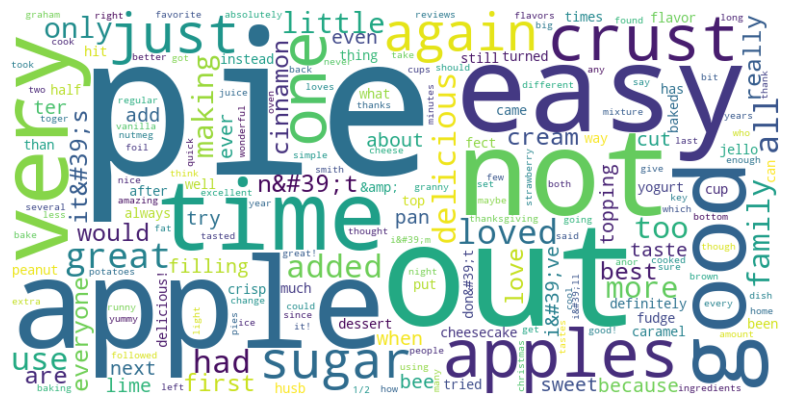

In [78]:
wordcloud = WordCloud(
    width=800, height=400, background_color='white').generate_from_frequencies(cnt_dict_tail5)

# represent wordcloud graph
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [80]:
top_agg_df = df.loc[df.food_category.isin(top5)].groupby(['recipe_name'])[['agg_rating', 'stars']].mean().reset_index()
tail_agg_df = df.loc[df.food_category.isin(tail5)].groupby(['recipe_name'])[['agg_rating', 'stars']].mean().reset_index()


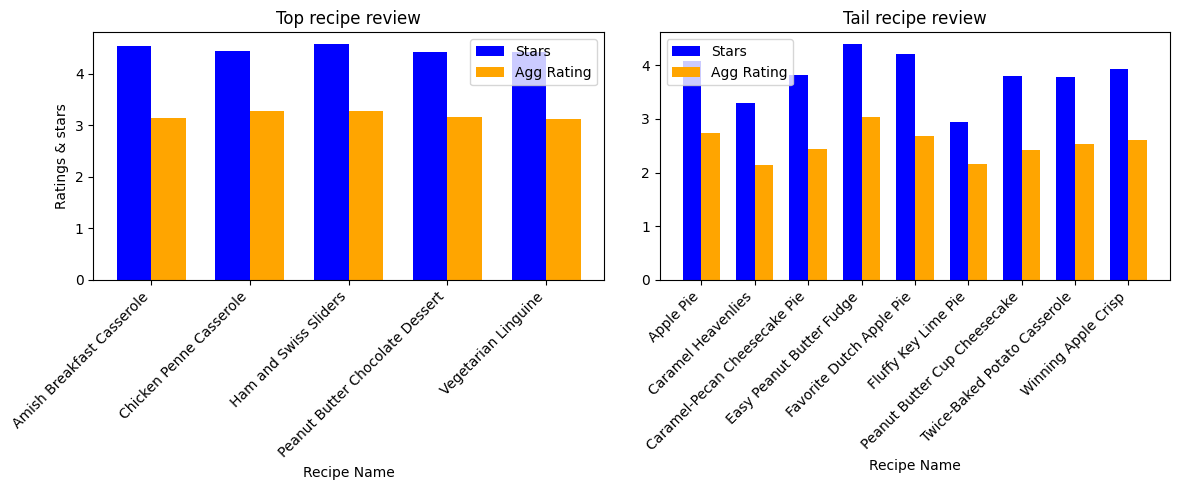

In [81]:
import matplotlib.pyplot as plt
import numpy as np


x1 = np.arange(len(top_agg_df.recipe_name))  # X 축 인덱스
x2 = np.arange(len(tail_agg_df.recipe_name))  # X 축 인덱스
width = 0.35  # 막대 너비

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1행 2열 서브플롯 생성

# 첫 번째 그래프 (Grouped Bar Chart)
ax1 = axes[0]
ax1.bar(x1 - width/2, top_agg_df.stars, width, label="Stars", color="blue")
ax1.bar(x1 + width/2, top_agg_df.agg_rating,width, label="Agg Rating", color="orange")

ax1.set_xlabel("Recipe Name")
ax1.set_ylabel("Ratings & stars")
ax1.set_title("Top recipe review")
ax1.set_xticks(x1)
ax1.set_xticklabels(top_agg_df.recipe_name, rotation=45,
                    ha="right")  # 🔹 X축 레이블 45도 회전
ax1.legend()

# 두 번째 그래프 (Twin Axes)
ax2 = axes[1]
ax2.bar(x2 - width/2, tail_agg_df.stars, width, label="Stars", color="blue")
ax2.bar(x2 + width/2, tail_agg_df.agg_rating,width, label="Agg Rating", color="orange")

ax2.set_xlabel("Recipe Name")
ax2.set_title("Ratings & stars")
ax2.set_title("Tail recipe review")
ax2.set_xticks(x2)
ax2.set_xticklabels(tail_agg_df.recipe_name, rotation=45, ha="right")  # 🔹 X축 레이블 45도 회전
ax2.legend(loc="upper left")

plt.tight_layout()  # 그래프 간격 조정
plt.show()


In [83]:
top_user_count = df.loc[df.food_category.isin(top5)].groupby(
    ['recipe_name']).agg({'user_name':'count', 'best_score' : 'max'}).reset_index()
tail_user_count = df.loc[df.food_category.isin(tail5)].groupby(
    ['recipe_name']).agg({'user_name': 'count', 'best_score': 'max'}).reset_index()


/tmp/ipykernel_2018592/3311809782.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(top_user_count.recipe_name, rotation=45,
/tmp/ipykernel_2018592/3311809782.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(tail_user_count.recipe_name,


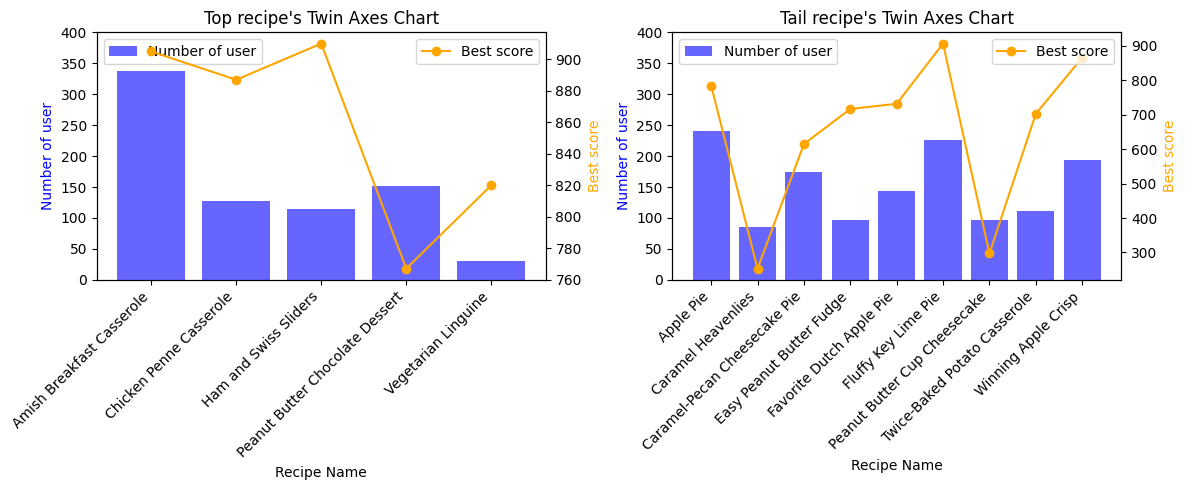

In [84]:
import matplotlib.pyplot as plt
import numpy as np


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # create subplot

# first graph
ax1 = axes[0]
ax1.bar(top_user_count.recipe_name, top_user_count.user_name,
        color="blue", alpha=0.6, label="Number of user")
ax1.set_ylabel("Number of user", color="blue")
ax1.set_ylim(0, 400)

ax4 = ax1.twinx()
ax4.plot(top_user_count.recipe_name, top_user_count.best_score, color="orange",
         marker="o", linestyle="-", label="Best score")
ax4.set_ylabel("Best score", color="orange")

ax1.set_xlabel("Recipe Name")
ax1.set_title("Top recipe's Twin Axes Chart")
ax1.set_xticklabels(top_user_count.recipe_name, rotation=45,
                    ha="right")  #  45 rotation of X label 
ax1.legend(loc="upper left")
ax4.legend(loc="upper right")

# second plot
ax2 = axes[1]
ax2.bar(tail_user_count.recipe_name, tail_user_count.user_name,
        color="blue", alpha=0.6, label="Number of user")
ax2.set_ylabel("Number of user", color="blue")
ax2.set_ylim(0, 400)

ax3 = ax2.twinx()
ax3.plot(tail_user_count.recipe_name, tail_user_count.best_score, color="orange",
         marker="o", linestyle="-", label="Best score")
ax3.set_ylabel("Best score", color="orange")

ax2.set_xlabel("Recipe Name")
ax2.set_title("Tail recipe's Twin Axes Chart")
ax2.set_xticklabels(tail_user_count.recipe_name,
                    rotation=45, ha="right")  # 45 rotation of X label
ax2.legend(loc="upper left")
ax3.legend(loc="upper right")

plt.tight_layout()  # adjust graph's interval 
plt.show()


In [86]:
top_user_repu = df.loc[df.food_category.isin(top5)].groupby(
    ['recipe_name']).agg({'user_reputation': 'sum'}).reset_index()
tail_user_repu = df.loc[df.food_category.isin(tail5)].groupby(
    ['recipe_name']).agg({'user_reputation': 'sum'}).reset_index()


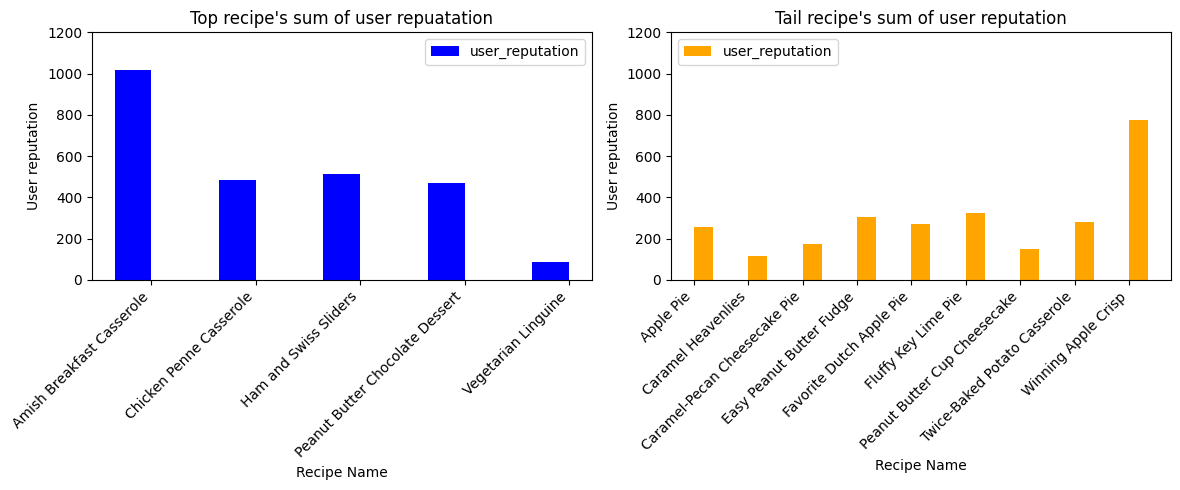

In [87]:
import matplotlib.pyplot as plt
import numpy as np


x1 = np.arange(len(top_user_repu.recipe_name))  # X 축 인덱스
x2 = np.arange(len(tail_user_repu.recipe_name))  # X 축 인덱스
width = 0.35  # 막대 너비

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1행 2열 서브플롯 생성

# 첫 번째 그래프 (Grouped Bar Chart)
ax1 = axes[0]
ax1.bar(x1 - width/2, top_user_repu.user_reputation,
        width, label="user_reputation", color="blue")

ax1.set_xlabel("Recipe Name")
ax1.set_ylabel("User reputation")
ax1.set_title("Top recipe's sum of user repuatation")
ax1.set_xticks(x1)
ax1.set_xticklabels(top_user_repu.recipe_name, rotation=45, ha="right")  # 🔹 X축 레이블 45도 회전
ax1.set_ylim(0, 1200)
ax1.legend()

# 두 번째 그래프 (Twin Axes)
ax2 = axes[1]
ax2.bar(x2 + width/2, tail_user_repu.user_reputation,
        width, label="user_reputation", color="orange")

ax2.set_xlabel("Recipe Name")
ax2.set_ylabel("User reputation")
ax2.set_title("Tail recipe's sum of user reputation")
ax2.set_xticks(x2)
ax2.set_xticklabels(tail_user_repu.recipe_name, rotation=45, ha="right")  # 🔹 X축 레이블 45도 회전
ax2.set_ylim(0, 1200)
ax2.legend(loc="upper left")

plt.tight_layout()  # 그래프 간격 조정
plt.show()


In [109]:
top_thumb = df.loc[df.food_category.isin(top5)].groupby(
    ['recipe_name']).agg({'thumbs_up': 'sum', 'thumbs_down' : 'sum'}).reset_index()
tail_thumb = df.loc[df.food_category.isin(tail5)].groupby(
    ['recipe_name']).agg({'thumbs_up': 'sum', 'thumbs_down': 'sum'}).reset_index()


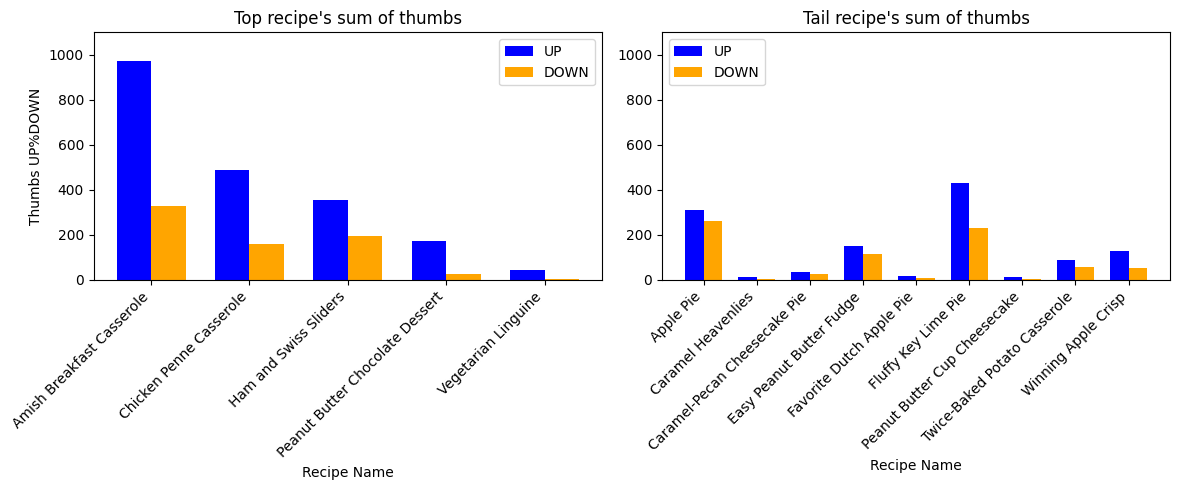

In [112]:
import matplotlib.pyplot as plt
import numpy as np


x1 = np.arange(len(top_thumb.recipe_name))  # X 축 인덱스
x2 = np.arange(len(tail_thumb.recipe_name))  # X 축 인덱스
width = 0.35  # 막대 너비

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1행 2열 서브플롯 생성

# 첫 번째 그래프 (Grouped Bar Chart)
ax1 = axes[0]
ax1.bar(x1 - width/2, top_thumb.thumbs_up,
        width, label="UP", color="blue")
ax1.bar(x1 + width/2, top_thumb.thumbs_down,
        width, label="DOWN", color="orange")

ax1.set_xlabel("Recipe Name")
ax1.set_ylabel("Thumbs UP%DOWN")
ax1.set_title("Top recipe's sum of thumbs")
ax1.set_xticks(x1)
ax1.set_xticklabels(top_thumb.recipe_name, rotation=45,
                    ha="right")  # 🔹 X축 레이블 45도 회전
ax1.set_ylim(0, 1100)
ax1.legend()

# 두 번째 그래프 (Twin Axes)
ax2 = axes[1]
ax2.bar(x2 - width/2, tail_thumb.thumbs_up, width, label="UP", color="blue")
ax2.bar(x2 + width/2, tail_thumb.thumbs_down,
        width, label="DOWN", color="orange")

ax2.set_xlabel("Recipe Name")
ax2.set_title("Thumbs UP%DOWN")
ax2.set_title("Tail recipe's sum of thumbs")
ax2.set_xticks(x2)
ax2.set_xticklabels(tail_thumb.recipe_name, rotation=45,
                    ha="right")  # 🔹 X축 레이블 45도 회전
ax2.set_ylim(0, 1100)
ax2.legend(loc="upper left")

plt.tight_layout()  # 그래프 간격 조정
plt.show()


In [90]:
df['new_agg_rating'] = df.stars*(3/5) + df.new_best_score * \
    (1/10) + df.new_like_ratio*(3/10)


In [91]:
# extract top 5 recipe
top5_new = list(df.groupby(['food_category'])[['new_agg_rating']].mean(
).sort_values(['new_agg_rating'], ascending=False).head(5).index)

# extract low 5 recipe

tail5_new = list(df.groupby(['food_category'])[
    ['new_agg_rating']].mean().sort_values(['new_agg_rating']).head(5).index)


In [92]:
print("original top recipe : ", top5)
print("new top recipe : ", top5_new)


original top recipe :  ['Casserole/Pasta', 'Sandwiches/Sliders', 'Desserts', 'Breakfast/Casserole', 'Pasta/Vegan']
new top recipe :  ['Casserole/Pasta', 'Sandwiches/Sliders', 'Desserts', 'Pasta/Vegan', 'Breakfast/Casserole']


In [93]:
print("original tail recipe : ", tail5)
print("new tail recipe : ", tail5_new)


original tail recipe :  ['Desserts/Cheesecake', 'Desserts/Pie', 'Casserole/Side', 'Desserts/Crisp', 'Desserts/Candy']
new tail recipe :  ['Desserts/Cheesecake', 'Desserts/Pie', 'Casserole/Side', 'Desserts/Crisp', 'Casserole/Mexican']


In [13]:
mult_reaction = df.loc[df['freq_reaction'] > 1]


In [35]:
# number of users who reply at least over 2 times.
print(len(mult_reaction.user_name.unique()))

print(len(df.user_name.unique()))

2072
13586
